https://python.langchain.com/docs/integrations/tools/

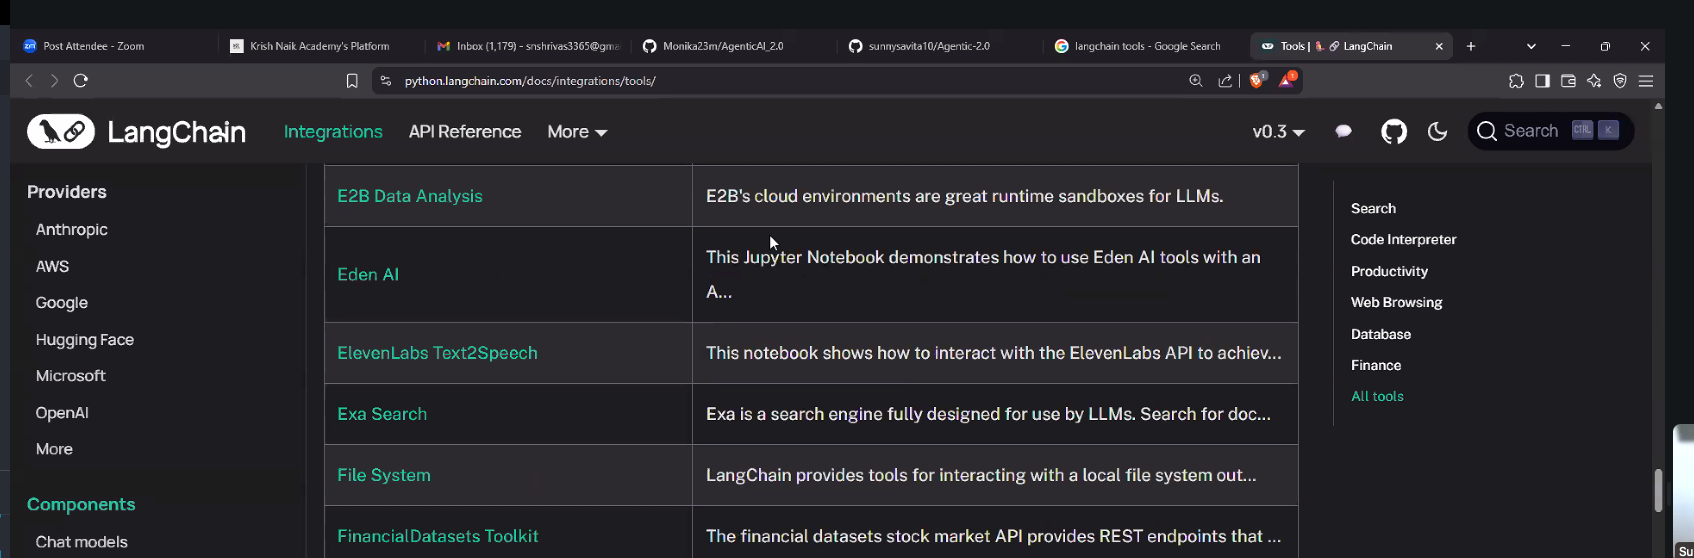

## Wikipedia

In [3]:
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper
from langchain_core.tools import tool
from langchain_core.language_models import BaseLanguageModel
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.callbacks import CallbackManager

In [ ]:
api_wrapper = WikipediaAPIWrapper(top_k_results=5, doc_content_chars_max=500)


In [5]:
wiki_tool = WikipediaQueryRun(api_wrapper=api_wrapper)

In [6]:
wiki_tool.description

'A wrapper around Wikipedia. Useful for when you need to answer general questions about people, places, companies, facts, historical events, or other subjects. Input should be a search query.'

In [7]:
wiki_tool.args

{'query': {'description': 'query to look up on wikipedia',
  'title': 'Query',
  'type': 'string'}}

In [13]:
wiki_tool.run({"query":"Python (programming language)"})

'Page: Python (programming language)\nSummary: Python is a high-level, general-purpose programming language. Its design philosophy emphasizes code readability with the use of significant indentation.\nPython is dynamically type-checked and garbage-collected. It supports multiple programming paradigms, including structured (particularly procedural), object-oriented and functional programming. It is often described as a "batteries included" language due to its comprehensive standard library.\nGuido va'

In [14]:
wiki_tool.run({"query":"RCB"})

/opt/homebrew/Caskroom/miniconda/base/envs/agentic/lib/python3.11/site-packages/wikipedia/wikipedia.py:389: GuessedAtParserWarning: No parser was explicitly specified, so I'm using the best available HTML parser for this system ("html.parser"). This usually isn't a problem, but if you run this code on another system, or in a different virtual environment, it may use a different parser and behave differently.

The code that caused this warning is on line 389 of the file /opt/homebrew/Caskroom/miniconda/base/envs/agentic/lib/python3.11/site-packages/wikipedia/wikipedia.py. To get rid of this warning, pass the additional argument 'features="html.parser"' to the BeautifulSoup constructor.

  lis = BeautifulSoup(html).find_all('li')


"Page: Royal Challengers Bengaluru\nSummary: Royal Challengers Bengaluru, formerly known as Royal Challengers Bangalore, commonly known as RCB, is a professional T20 franchise cricket team based in Bengaluru, Karnataka, that competes in the Indian Premier League. Founded in 2008 by United Spirits, the team's home ground is M. Chinnaswamy Stadium. RCB won their first title in 2025. The team has also finished as the runners-up on three occasions: in 2009, 2011, and 2016. They have also qualified for"

## youtube search

In [15]:
from langchain_community.tools import YouTubeSearchTool

In [19]:
tool = YouTubeSearchTool()

In [20]:
tool.run("Python programming language")

"['https://www.youtube.com/watch?v=3dy_PYF9xOI&pp=ygUbUHl0aG9uIHByb2dyYW1taW5nIGxhbmd1YWdl', 'https://www.youtube.com/watch?v=UrsmFxEIp5k&pp=ygUbUHl0aG9uIHByb2dyYW1taW5nIGxhbmd1YWdl']"

## Internet Cruling

In [16]:
from langchain_community.tools.tavily_search import TavilySearchResults
tavily_tool = TavilySearchResults(tavily_api_key="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"
)
tavily_tool.run({"query": "Python programming language"})

[{'title': 'Python (programming language) - Wikipedia',
  'url': 'https://en.wikipedia.org/wiki/Python_(programming_language)',
  'content': '**Python** is a [high-level](https://en.wikipedia.org/wiki/High-level_programming_language "High-level programming language"), [general-purpose programming language](https://en.wikipedia.org/wiki/General-purpose_programming_language "General-purpose programming language"). Its design philosophy emphasizes [code readability](https://en.wikipedia.org/wiki/Code_readability "Code readability") with the use of [significant indentation](https://en.wikipedia.org/wiki/Significant_indentation [...] Python is a [multi-paradigm programming language](https://en.wikipedia.org/wiki/Multi-paradigm_programming_language "Multi-paradigm programming language"). Object-oriented programming and structured programming are fully supported, and many of their features support functional programming and [aspect-oriented programming](https://en.wikipedia.org/wiki/Aspect-or

In [18]:
tavily_tool.invoke({"query": "what is happen in the world today?"})

[{'title': 'Latest news from around the world | The Guardian',
  'url': 'https://www.theguardian.com/world',
  'content': '### Russia attacks Ukraine with missiles and drones – as it happened\n\n![](https://i.guim.co.uk/img/uploads/2022/02/10/TiF_FINAL_3000x3000.jpg?width=120&dpr=1&s=none&crop=1%3A1)\n\n### The Swiss village buried by a glacier collapse – podcast\n\n## Middle East\n\n![People walk along a road to receive aid packages in Rafah](https://i.guim.co.uk/img/media/d4c45bf36b10367d28c8fe85cb005210247d5ec5/213_0_3000_2400/master/3000.jpg?width=360&dpr=1&s=none&crop=5%3A4) [...] ### Indian troops shoot dead Pakistani man crossing frontier, officials say\n\n![Sheikh Hasina](https://i.guim.co.uk/img/media/b8acda7571b0b6a5f471c1fb6798ccffdfaa27c9/219_0_2180_1745/master/2180.jpg?width=240&dpr=1&s=none&crop=5%3A4)\n\n### NCA freezes £90m of London property linked to former Bangladesh regime\n\n![Donald Trump holding phone](https://i.guim.co.uk/img/media/8fd4a1fe345fd870287930729c7496

In [ ]:
import os
os.environ["GOOGLE_API_KEY"] = os.environ("")  # Replace with your actual API key

from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import HumanMessage

llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash")

# Simple text invocation
result = llm.invoke("Sing a ballad of LangChain.")
print(result.content)

DefaultCredentialsError: ('File /dev/null is not a valid json file.', JSONDecodeError('Expecting value: line 1 column 1 (char 0)'))

## Custom tool

In [21]:
from langchain.agents import tool

docstring mandatory to make function to tool

In [38]:
## code to multiply two numbers using a tool

## ?
# review tool decurator
# Can you share best practices for tools development and usage?

@tool
def multiply_numbers(a: int, b: int) -> int:
    """Multiplies two numbers."""
    return a * b
def multiply_numbers_with_lm(a: int, b: int, llm: BaseLanguageModel) -> int:
    """Multiplies two numbers using a language model."""
    prompt = PromptTemplate(
        input_variables=["a", "b"],
        template="Multiply {a} and {b}.",
    )
    formatted_prompt = prompt.format(a=a, b=b)
    response = llm.generate([formatted_prompt])
    return int(response.generations[0][0].text.strip())

Bad pipe message: %s [b'96\xeb`\xfb8\x0e\xa9{\x07Uu\xd1_\xa1\x07\xea)\x00\x01|\x00\x00\x00\x01\x00\x02\x00\x03\x00\x04\x00\x05\x00\x06\x00\x07\x00\x08\x00\t\x00\n\x00\x0b\x00\x0c\x00\r\x00\x0e\x00\x0f\x00\x10\x00\x11\x00\x12\x00\x13\x00\x14\x00\x15\x00\x16\x00\x17\x00\x18\x00\x19\x00\x1a\x00\x1b\x00/\x000\x001\x002\x003\x004\x005\x006\x007\x008\x009\x00:\x00;\x00<\x00=\x00>\x00?\x00@\x00A\x00B\x00C\x00D\x00E\x00F\x00g\x00h\x00i\x00j\x00k\x00l\x00m\x00\x84\x00\x85\x00\x86\x00\x87\x00\x88\x00\x89\x00\x96\x00\x97\x00\x98\x00\x99\x00\x9a\x00\x9b\x00\x9c\x00\x9d\x00\x9e\x00\x9f\x00\xa0\x00\xa1\x00\xa2\x00\xa3\x00\xa4\x00\xa5\x00\xa6\x00\xa7\x00\xba\x00\xbb\x00\xbc\x00\xbd\x00\xbe\x00\xbf\x00\xc0\x00\xc1\x00\xc2\x00\xc3\x00\xc4\x00\xc5\x13\x01\x13\x02\x13\x03\x13', b'\x05\xc0\x01', b"\xc0\x03\xc0\x04\xc0\x05\xc0\x06\xc0\x07\xc0\x08\xc0\t\xc0\n\xc0\x0b\xc0\x0c\xc0\r\xc0\x0e\xc0\x0f\xc0\x10\xc0\x11\xc0\x12\xc0\x13\xc0\x14\xc0\x15\xc0\x16\xc0\x17\xc0\x18\xc0\x19\xc0#\xc0$\xc0%\xc0&\xc0'\xc0(\xc

In [24]:
multiply_numbers.invoke({"a": 3, "b": 4})

12

In [26]:
multiply_numbers.name


'multiply_numbers'

In [27]:
multiply_numbers.description


'Multiplies two numbers.'

In [28]:
multiply_numbers.args

{'a': {'title': 'A', 'type': 'integer'},
 'b': {'title': 'B', 'type': 'integer'}}

##tool is function only

In [33]:
@tool
def get_word_length(word: str) -> int:
    """Returns the length of the given word."""
    return len(word)



In [ ]:
get_word_length.invoke({"word": "hello"})

In [35]:
get_word_length.name

'get_word_length'

In [36]:
get_word_length.description

'Returns the length of the given word.'

In [37]:
get_word_length.args

{'word': {'title': 'Word', 'type': 'string'}}

## write text about above cell to make custom tool using tool decurator and function
To create a custom tool in LangChain, you can use the @tool decorator to turn any Python function into a tool that can be used by agents. The function must include a docstring, which will be used as the tool's description. For example, in the above cell, we define a function get_word_length that takes a word as input and returns its length. By adding the @tool decorator, this function becomes a tool that can be invoked with arguments as a dictionary. This approach allows you to easily create and register custom tools for your agent workflows.

`run` call in older version
`invoke` in latest version